# NB3: Bias Adjustment of Regional Climate Models using climate4R

## 1. Introduction
Climate simulations constitute one of the main sources of information for climate change impact assessments. Nevertheless, even state-of-the-art regional climate models (RCMs) are imperfect representations of the climate system, so they often exhibit systematic discrepancies with respect to observational datasets. These discrepancies, commonly referred to as model biases, may originate from many different sources, including:

* approximations in the governing equations;
* imperfect parameterisations of unresolved physical processes;
* limitations in the driving global climate model;
* uncertainties in land-surface characteristics;
* finite spatial resolution.

As a consequence, simulated temperatures may be consistently warmer or colder than observations, precipitation may occur too frequently or too rarely, and the seasonal cycle may be shifted.
Bias adjustment/correction attempts to reduce these systematic differences by modifying selected statistical properties of the simulated climate while preserving the modelled climate change signal as much as possible.

This notebook introduces the main bias adjustment techniques currently available in the climate4R framework through the `downscaleR` package.

Rather than focusing exclusively on the implementation, the notebook also discusses the statistical assumptions behind each method, their advantages and limitations, and the situations in which each approach is most appropriate. In this regard, note that bias adjustment is often misunderstood. It is important to emphasise that bias adjustment does not improve the climate model itself. Instead, it modifies the model output in order to make it statistically more consistent with a chosen reference dataset.

### 1.1. Learning Objectives
After completing this notebook, you should be able to

* understand why bias adjustment is required;
* calibrate bias adjustment methods using historical data;
* apply the calibrated methods to correct climate simulations;
* evaluate bias-corrected data using multiple diagnostics;
* recognise the strengths and limitations of each bias adjustment method.

## 2. Preparing the Working Environment
First, it is necessary to define a few parameters controlling the analysis to be undertaken and load the required libraries.

The climate4R ecosystem provides a collection of packages specifically designed for handling climate data. These packages  (`loadeR`, `transformeR`, `visualizeR`, `downscaleR`) allow users to manipulate both station observations and gridded datasets through a common data structure, making subsequent analyses considerably easier (including temporal and spatial subsetting, regridding, visualization, bias correction and statistical downscaling).

In addition, some extra libraries outside climate4R (`RColorBrewer`, `lattice`, `gridExtra`) are also loaded to facilitate the production of publication-quality figures.

In [1]:
rm(list = ls())

## params ##
dirbase = "/home/jovyan"
dirdata.obs = sprintf("%s/data/obs", dirbase)
dirdata.era5 = "https://thredds.climate.ifca.es/thredds/dodsC/fao/trainings/pakistan-202608/data/era5"
dirdata.cordex = "https://thredds.climate.ifca.es/thredds/dodsC/fao/trainings/pakistan-202608/data/cordex-core"

#lon = c(60, 80)
#lat = c(22, 38)

# lon = c(66, 75)
# lat = c(24, 35)

lon = c(66, 68)  # small region of study (encompassing Karachi)
lat = c(24, 26)  # small region of study (encompassing Karachi)

## libraries ##
library(loadeR)
library(transformeR)
library(visualizeR)
library(downscaleR)
library(sf)

## auxiliary functions ##
source(sprintf("%s/notebooks/auxiliary_functions.R", dirbase))

Loading required package: rJava

Loading required package: loadeR.java

Java version 23x amd64 by N/A detected

The maximum JVM heap space available is: 2.00 GB

NetCDF Java Library Version: 5.10.0 (Built-On: NA) loaded and ready

You can manually set the NetCDF Java Library version before loading the package:
options(loadeR.java_forced_version = "X.Y.Z")
library(loadeR.java)

netCDF-Java CLASSPATH from env LOADER_JAVA_CLASSPATH + bundled java package directory: /home/rodri/miniforge3/envs/C4R-pakistan/lib/java/toolsUI.jar:/home/rodri/miniforge3/envs/C4R-pakistan/lib/R/library/loadeR.java/java:/home/rodri/miniforge3/envs/C4R-pakistan/lib/R/library/loadeR.java/java/netcdfAll-4.6.0-SNAPSHOT.jar

Loading required package: climate4R.UDG

climate4R.UDG version 0.2.6 (2023-06-26) is loaded

Please use 'citation("climate4R.UDG")' to cite this package.

loadeR version 1.8.4 (2025-08-07) is loaded

Please use 'citation("loadeR")' to cite this package.




    _______   ____  ___________________  __  ________ 
   / ___/ /  / /  |/  / __  /_  __/ __/ / / / / __  / 
  / /  / /  / / /|_/ / /_/ / / / / __/ / /_/ / /_/_/  
 / /__/ /__/ / /  / / __  / / / / /__ /___  / / \ \ 
 \___/____/_/_/  /_/_/ /_/ /_/  \___/    /_/\/   \_\ 
 
      github.com/SantanderMetGroup/climate4R



transformeR version 2.2.2 (2023-10-26) is loaded


Get the latest stable version (2.2.5) using <devtools::install_github('SantanderMetGroup/transformeR')>

Please see 'citation("transformeR")' to cite this package.

visualizeR version 1.6.4 (2023-10-26) is loaded

Please see 'citation("visualizeR")' to cite this package.

downscaleR version 3.3.4 (2023-06-22) is loaded

Please use 'citation("downscaleR")' to cite this package.

Linking to GEOS 3.12.1, GDAL 3.8.5, PROJ 9.4.0; sf_use_s2() is TRUE



## 3. Loading ERA5 and CORDEX-CORE Data

Every bias correction method requires two datasets to be trained:

* an observational reference;
* a model simulation which covers, at least, the same period of the observational reference. 

During this calibration period (typically the recent past), the statistical relationship between observations and simulations is estimated. The resulting correction function is subsequently applied to adjust the model simulations for new periods (e.g. future projections). Note that this implies relying on the assumption that model biases remain approximately stationary over time.

The first step is therefore to load the datasets that will be used throughout most of the remainder of the notebook. 
We will consider ERA5 as observational reference, plus historical and future simulations from a CORDEX-CORE regional climate model. In particular, we will consider the REMO2015 RCM, driven by the HadGEM2-ES GCM, to illustrate the complete workflow. Nonetheless, note that the same procedure here presented could be readily extended to additional simulations.

To alleviate a bit the computational cost of the workflow presented hereafter, the historical analyses are restricted to the 1981-2000 reference period (both for ERA5 and RCM simulations under the historical scenario), while the future projection is limited to 2061-2099 (for the RCM simulations under the RCP85). 

In [2]:
## loading tmax from ERA5 ##
era5 = loadGridData(sprintf("%s/tmax.nc", dirdata.era5),
                     var = "tmax", 
                     lonLim = lon, latLim = lat,
                     years = 1981:2000)
getShape(era5)

[2026-07-17 11:20:05.685766] Opening dataset...

[2026-07-17 11:20:06.616459] The dataset was successfuly opened

[2026-07-17 11:20:06.623247] Defining geo-location parameters

[2026-07-17 11:20:06.664173] Defining time selection parameters

[2026-07-17 11:20:06.778906] Retrieving data subset ...

[2026-07-17 11:20:12.090809] Done



time  lat  lon 
7305    9    9

In [3]:
#####################################################################
## loading tmax from CORDEX-CORE (historical and RCP8.5 scenarios) ##
#####################################################################

# model = c("HadGEM2-ES_REMO2015", "MPI-ESM-LR_REMO2015", "MPI-ESM-MR_RegCM4-7", "NorESM1-M_REMO2015","NorESM1-M_RegCM4-7")
model = c("HadGEM2-ES_REMO2015")

## historical ##
cordex.hist = loadGridData(sprintf("%s/%s_historical_tmax.nc", dirdata.cordex, model),
                     var = "tmax", lonLim = lon, latLim = lat,
                     years = 1981:2000)
getShape(cordex.hist)

## RCP8.5 ##
cordex.rcp85 = loadGridData(sprintf("%s/%s_rcp85_tmax.nc", dirdata.cordex, model),
                     var = "tmax", lonLim = lon, latLim = lat,
                     years = 2061:2099)
getShape(cordex.rcp85)

[2026-07-17 11:20:12.242711] Opening dataset...

[2026-07-17 11:20:12.48023] The dataset was successfuly opened

[2026-07-17 11:20:12.482899] Defining geo-location parameters

[2026-07-17 11:20:12.505216] Defining time selection parameters

[2026-07-17 11:20:12.597145] Retrieving data subset ...

[2026-07-17 11:20:16.621323] Done



time  lat  lon 
7165    9    9

[2026-07-17 11:20:16.760803] Opening dataset...

[2026-07-17 11:20:17.016217] The dataset was successfuly opened

[2026-07-17 11:20:17.020677] Defining geo-location parameters

[2026-07-17 11:20:17.045558] Defining time selection parameters

[2026-07-17 11:20:17.545973] Retrieving data subset ...

[2026-07-17 11:20:22.966048] Done



time   lat   lon 
13971     9     9

Noteworthy, all the CORDEX-CORE simulations have been already regridded to the ERA5's regular grid of 0.25º resolution. 

In [4]:
getGrid(era5)
identical(getGrid(era5), getGrid(cordex.hist))
identical(getGrid(era5), getGrid(cordex.rcp85))

$x
[1] 66 68

$y
[1] 24 26

attr(,"projection")
[1] "LatLonProjection"
attr(,"resX")
[1] 0.25
attr(,"resY")
[1] 0.25

[1] TRUE

[1] TRUE

After loading the datasets, the temporal coverage of each one is inspected by examining the range of available dates. This simple verification step confirms that the observational reference, the historical simulation and the future projection cover the expected time periods before any preprocessing or bias adjustment is performed.

In [5]:
range(era5$Dates$start)
range(cordex.hist$Dates$start)
range(cordex.rcp85$Dates$start)

[1] "1981-01-01 00:00:00 GMT" "2000-12-31 00:00:00 GMT"

[1] "1981-01-01 12:00:00 GMT" "2000-12-30 12:00:00 GMT"

[1] "2061-01-01 12:00:00 GMT" "2099-12-30 12:00:00 GMT"

## 4. Harmonizing ERA5 and CORDEX-CORE Data

First, all temperature fields are converted from Kelvin (K), the standard unit used by most climate models, to degrees Celsius (°C). Using consistent physical units is essential before applying any statistical comparison or bias correction method.

In [6]:
## converting K to degC ##
era5 = gridArithmetics(era5, 273.15, operator = "-")
cordex.hist = gridArithmetics(cordex.hist, 273.15, operator = "-")
cordex.rcp85 = gridArithmetics(cordex.rcp85, 273.15, operator = "-")

## 5. Raw Climate Change Signal
Before applying any bias adjustment method, it is useful to examine the climate change signal directly simulated by the RCM. In this notebook, this signal is expressed as a *delta*, which is computed as the difference between the future and historical climatologies for maximum temperature.

To investigate how projected warming evolves over time, two future periods are analysed separately: 2061-2080 (mid-century) and 2081-2099 (late-century). For each period, a climatological mean is first calculated and then compared with the historical one (1981-2000), producing two maps that represent the projected change in maximum temperature.

Displaying the two delta maps side by side facilitates the comparison of both the magnitude and the spatial distribution of the projected warming. These maps provide a useful baseline for the remainder of the notebook, where the same analysis will be repeated after bias adjustment to assess whether the correction methods preserve the simulated climate change signal.

[2026-07-17 11:20:24.055652] - Computing climatology...

[2026-07-17 11:20:24.062074] - Done.

[2026-07-17 11:20:24.064975] - Computing climatology...

[2026-07-17 11:20:24.07059] - Done.

[2026-07-17 11:20:24.108235] - Computing climatology...

[2026-07-17 11:20:24.113774] - Done.

[2026-07-17 11:20:24.116519] - Computing climatology...

[2026-07-17 11:20:24.12626] - Done.



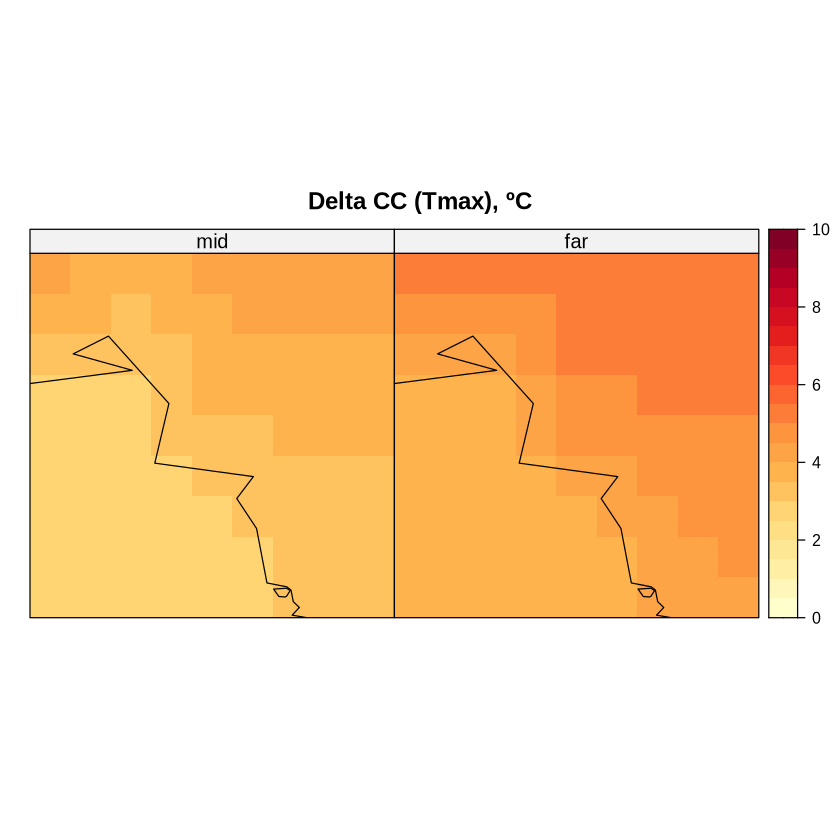

In [7]:
## delta: cc signals ##
delta.mid = gridArithmetics(climatology(subsetGrid(cordex.rcp85, years = 2061:2080)),
                            climatology(cordex.hist), operator = "-")
delta.far = gridArithmetics(climatology(subsetGrid(cordex.rcp85, years = 2081:2099)),
                            climatology(cordex.hist), operator = "-")
spatialPlot(makeMultiGrid(delta.mid, delta.far, skip.temporal.check = TRUE),
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(2, 1),
            main = "Delta CC (Tmax), ºC",
            names.attr = c("mid", "far"),
            color.theme = "YlOrRd",
            set.min = 0, set.max = 10, at = seq(0, 10, 0.5))

## 6. Bias Correction
### 6.1. The Scaling method
The first bias adjustment technique considered in this notebook is the Scaling method, one of the simplest approaches available in `downscaleR`. The method is first calibrated using the historical reference period (1981-2000), based on ERA5 observations and the historical CORDEX-CORE simulation. During this calibration stage, the systematic differences between the model and the observational dataset are estimated, allowing a correction function to be derived.

To evaluate the performance of the method under independent data, the historical scenario is calibrated using a two-fold cross-validation scheme. This procedure divides the historical record into two subsets, alternately using one for calibration and the other for validation. This provides a more robust assessment of the method than calibrating and evaluating on exactly the same data.

Once the correction has been calibrated, it is applied to the future RCP8.5 simulation. Unlike the historical case, no cross-validation is applied because the objective is no longer to evaluate the method, but to transfer the statistical correction learned from the historical period to the future climate projection. This step assumes that the statistical relationship estimated during the historical period remains valid under future climate conditions, allowing the future simulation to be bias-adjusted while preserving its projected climate change signal.

In [8]:
####################
## scaling method ##
####################

## bias correcting the historical scenario ##
cordex.hist.bc.scaling = biasCorrection(era5, cordex.hist, method = "scaling", 
                                        cross.val = "kfold", folds = 2)
cordex.hist.bc.scaling$Dates$start = as.character(cordex.hist.bc.scaling$Dates$start)  # manually fixing bug with dates after bias correction  
cordex.hist.bc.scaling$Dates$end = as.character(cordex.hist.bc.scaling$Dates$end)  # manually fixing bug with dates after bias correction

[2026-07-17 11:20:28.112188] Trying to determine the time zone...

[2026-07-17 11:20:28.113578] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:20:28.211773] Already complete date record. Nothing was done

[2026-07-17 11:20:28.225149] Trying to determine the time zone...

[2026-07-17 11:20:28.22696] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:20:28.329542] Trying to determine the time zone...

[2026-07-17 11:20:28.330695] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

Validation 1, 1 remaining

[2026-07-17 11:20:28.856651] Argument precipitation is set as FALSE, please ensure that this matches your data.

[2026-07-17 11:20:29.085753] Number of windows considered: 1...

[2026-07-17 11:20:29.091893] Bias-correcting 1 members separately...

[2026-07-17 11:20:29.236669] Done.

Validation 2, 0 remaining

[2026-07-17 11:20:29.535997]

In [9]:
## bias correcting the RCP8.5 scenario ##
cordex.rcp85.bc.scaling = biasCorrection(era5, cordex.hist, newdata = cordex.rcp85, 
                                         method = "scaling", 
                                         cross.val = "none")
cordex.rcp85.bc.scaling$Dates$start = as.character(cordex.rcp85.bc.scaling$Dates$start)  # manually fixing bug with dates after bias correction
cordex.rcp85.bc.scaling$Dates$end = as.character(cordex.rcp85.bc.scaling$Dates$end)  # manually fixing bug with dates after bias correction

[2026-07-17 11:20:29.824789] Trying to determine the time zone...

[2026-07-17 11:20:29.825867] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:20:30.097588] Already complete date record. Nothing was done

[2026-07-17 11:20:30.103087] Trying to determine the time zone...

[2026-07-17 11:20:30.104394] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:20:30.202028] Trying to determine the time zone...

[2026-07-17 11:20:30.203854] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:20:30.991009] Argument precipitation is set as FALSE, please ensure that this matches your data.

[2026-07-17 11:20:31.588719] Number of windows considered: 1...

[2026-07-17 11:20:31.602902] Bias-correcting 1 members separately...

[2026-07-17 11:20:32.901935] Done.



### 6.2. The EQM method
The second bias adjustment technique explored in this notebook is Empirical Quantile Mapping (EQM), one of the most widely used  statistical methods in climate change applications. Unlike the Scaling method, which primarily corrects the mean climate, EQM adjusts the entire distribution of the simulated variable by matching the empirical cumulative distribution functions of the observations and the climate model.

As for the Scaling method, EQM is first calibrated using the reference period, based on ERA5 and the historical CORDEX-CORE simulation. A two-fold cross-validation strategy is employed to assess the performance of the correction on independent subsets of the historical record, reducing the risk of overfitting and providing a more reliable evaluation of the method.

Once the calibration is completed, the derived correction is applied to the future RCP8.5 simulation without cross-validation. 

Because EQM corrects the full distribution of the variable rather than only its average behaviour, it is generally expected to provide a more realistic representation of climate variability and extremes. In the following sections, its performance will be compared with that of the simpler Scaling method to evaluate how the choice of bias adjustment technique influences the resulting climate projections.

In [10]:
####################
## EQM method ##
####################

## bias correcting the historical scenario ##
cordex.hist.bc.eqm = biasCorrection(era5, cordex.hist, method = "eqm", 
                                    cross.val = "kfold", folds = 2)
cordex.hist.bc.eqm$Dates$start = as.character(cordex.hist.bc.eqm$Dates$start)  # manually fixing bug with dates after bias correction
cordex.hist.bc.eqm$Dates$end = as.character(cordex.hist.bc.eqm$Dates$end)  # manually fixing bug with dates after bias correction

[2026-07-17 11:20:32.935075] Trying to determine the time zone...

[2026-07-17 11:20:32.936298] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:20:33.013317] Already complete date record. Nothing was done

[2026-07-17 11:20:33.019104] Trying to determine the time zone...

[2026-07-17 11:20:33.020726] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:20:33.354138] Trying to determine the time zone...

[2026-07-17 11:20:33.355827] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

Validation 1, 1 remaining

[2026-07-17 11:20:33.587228] Argument precipitation is set as FALSE, please ensure that this matches your data.

[2026-07-17 11:20:33.845914] Number of windows considered: 1...

[2026-07-17 11:20:33.852034] Bias-correcting 1 members separately...

[2026-07-17 11:20:34.560663] Done.

Validation 2, 0 remaining

[2026-07-17 11:20:34.680705

In [11]:
## bias correcting the RCP8.5 scenario ##
cordex.rcp85.bc.eqm = biasCorrection(era5, cordex.hist, newdata = cordex.rcp85, 
                                     method = "eqm", 
                                     cross.val = "none")
cordex.rcp85.bc.eqm$Dates$start = as.character(cordex.rcp85.bc.eqm$Dates$start)  # manually fixing bug with dates after bias correction
cordex.rcp85.bc.eqm$Dates$end = as.character(cordex.rcp85.bc.eqm$Dates$end)  # manually fixing bug with dates after bias correction

[2026-07-17 11:20:35.870116] Trying to determine the time zone...

[2026-07-17 11:20:35.871218] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:20:36.236612] Already complete date record. Nothing was done

[2026-07-17 11:20:36.24191] Trying to determine the time zone...

[2026-07-17 11:20:36.243185] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:20:36.335859] Trying to determine the time zone...

[2026-07-17 11:20:36.337596] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:20:37.128855] Argument precipitation is set as FALSE, please ensure that this matches your data.

[2026-07-17 11:20:37.489201] Number of windows considered: 1...

[2026-07-17 11:20:37.503287] Bias-correcting 1 members separately...

[2026-07-17 11:20:40.231012] Done.



## 7. Bias-Corrected Climate Change Signal
A fundamental question in climate change applications is whether bias adjustment modifies the projected climate change signal provided by the raw model simulations.

To investigate this issue, the notebook recomputes the temperature deltas after applying both correction methods.

The six resulting maps allow a direct comparison between

* the raw simulation,
* the Scaling correction,
* the EQM correction,

for both mid-century and late-century conditions.

This comparison illustrates an important aspect of statistical bias adjustment: an effective correction should reduce historical biases while preserving, as much as possible, the spatial patterns and magnitude of the projected climate change.

In [12]:
## projected deltas by the scaling method ##
delta.mid.bc.scaling = gridArithmetics(climatology(subsetGrid(cordex.rcp85.bc.scaling, years = 2061:2080)),
                                       climatology(cordex.hist.bc.scaling), operator = "-")
delta.far.bc.scaling = gridArithmetics(climatology(subsetGrid(cordex.rcp85.bc.scaling, years = 2081:2099)),
                                       climatology(cordex.hist.bc.scaling), operator = "-")

[2026-07-17 11:20:40.552275] - Computing climatology...

[2026-07-17 11:20:40.559345] - Done.

[2026-07-17 11:20:40.56449] - Computing climatology...

[2026-07-17 11:20:40.570256] - Done.

[2026-07-17 11:20:40.594981] - Computing climatology...

[2026-07-17 11:20:40.60104] - Done.

[2026-07-17 11:20:40.60565] - Computing climatology...

[2026-07-17 11:20:40.611218] - Done.



In [13]:
## projected deltas by the EQM method ##
delta.mid.bc.eqm = gridArithmetics(climatology(subsetGrid(cordex.rcp85.bc.eqm, years = 2061:2080)),
                                   climatology(cordex.hist.bc.scaling), operator = "-")
delta.far.bc.eqm = gridArithmetics(climatology(subsetGrid(cordex.rcp85.bc.eqm, years = 2081:2099)),
                                   climatology(cordex.hist.bc.scaling), operator = "-")

[2026-07-17 11:20:40.650296] - Computing climatology...

[2026-07-17 11:20:40.656402] - Done.

[2026-07-17 11:20:40.662865] - Computing climatology...

[2026-07-17 11:20:40.671931] - Done.

[2026-07-17 11:20:40.704084] - Computing climatology...

[2026-07-17 11:20:40.710542] - Done.

[2026-07-17 11:20:40.715711] - Computing climatology...

[2026-07-17 11:20:40.727859] - Done.



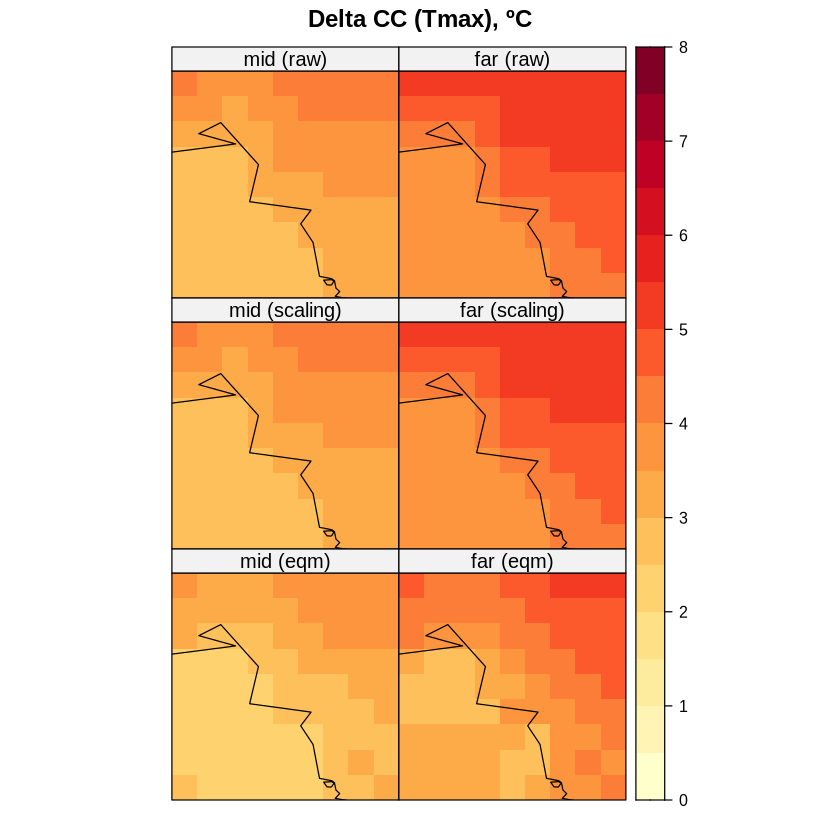

In [14]:
## plotting projected deltas by the scaling and EQM methods, altogether ##
spatialPlot(makeMultiGrid(delta.mid, delta.far,
                          delta.mid.bc.scaling, delta.far.bc.scaling, 
                          delta.mid.bc.eqm, delta.far.bc.eqm,
                          skip.temporal.check = TRUE),
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(2, 3),
            main = "Delta CC (Tmax), ºC",
            names.attr = c("mid (raw)", "far (raw)", 
                           "mid (scaling)", "far (scaling)", 
                           "mid (eqm)", "far (eqm)"),
            color.theme = "YlOrRd",
            set.min = 0, set.max = 8, at = seq(0, 8, 0.5))

## 8. Spatially-Averaged Historical and Future Time Series
Once the bias-corrected projections have been generated, the notebook combines the historical and future simulations into continuous time series (`bindGrid()` function).

Displaying the complete temporal evolution provides a different perspective from the climatological maps shown previously. Instead of focusing on average changes, the time series illustrate how temperatures evolve from the historical reference period towards the future climate, spatially averaged for the entire country.

The comparison includes

* the raw RCM simulation,
* the Scaling-adjusted simulation,
* the EQM-adjusted simulation.

Although ERA5 is only available for the historical period, it provides a useful benchmark for assessing how well each correction method reproduces the observed climate before the projections diverge into the future.

Let's start by plotting the daily time series.

pad applied on the interval: day

pad applied on the interval: day

pad applied on the interval: day

pad applied on the interval: day



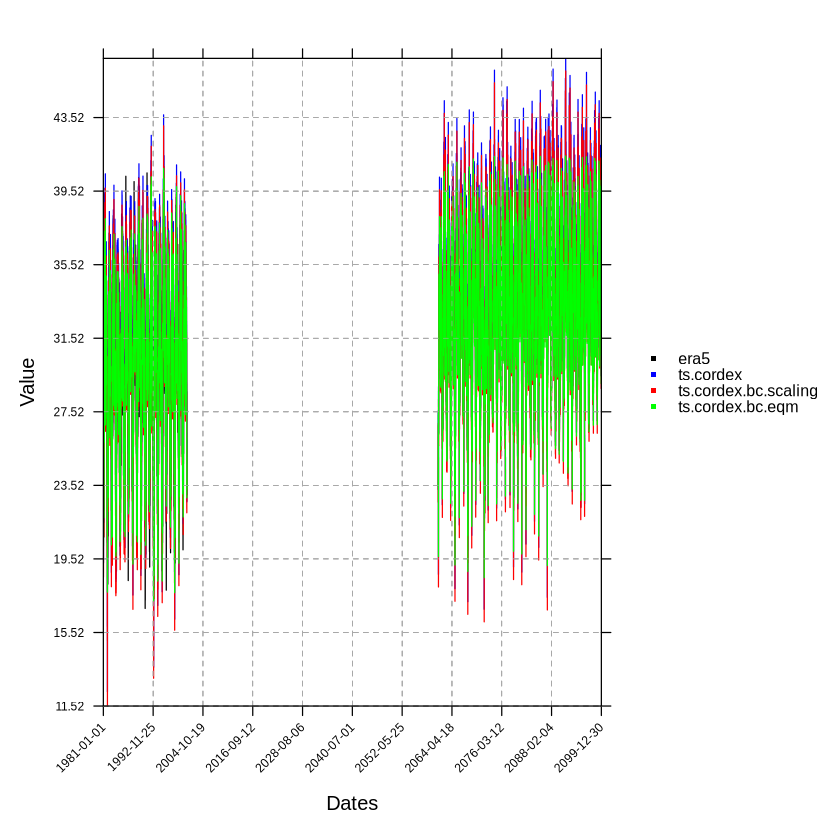

In [15]:
## creating continuous (daily) time series ##
ts.cordex = bindGrid(cordex.hist, cordex.rcp85, dimension = "time")
ts.cordex.bc.scaling = bindGrid(cordex.hist.bc.scaling, cordex.rcp85.bc.scaling, dimension = "time")
ts.cordex.bc.eqm = bindGrid(cordex.hist.bc.eqm, cordex.rcp85.bc.eqm, dimension = "time")

## plotting ##
temporalPlot(era5, ts.cordex, ts.cordex.bc.scaling, ts.cordex.bc.eqm,
            cols = c("black", "blue", "red", "green"))

Daily temperatures contain considerable short-term variability associated with individual weather events. To highlight long-term climate evolution, it is preferred to aggregate the daily data to the yearly scale. This temporal aggregation filters out much of the day-to-day variability, making long-term warming trends easier to identify.

[2026-07-17 11:20:55.138956] Performing annual aggregation...

[2026-07-17 11:20:55.153579] Done.

[2026-07-17 11:20:55.164062] Performing annual aggregation...

[2026-07-17 11:20:55.178416] Done.

[2026-07-17 11:20:55.456902] Performing annual aggregation...

[2026-07-17 11:20:55.484527] Done.

[2026-07-17 11:20:55.497715] Performing annual aggregation...

[2026-07-17 11:20:55.518725] Done.

[2026-07-17 11:20:55.535568] Performing annual aggregation...

[2026-07-17 11:20:55.586309] Done.

[2026-07-17 11:20:55.598132] Performing annual aggregation...

[2026-07-17 11:20:55.618391] Done.

[2026-07-17 11:20:55.63508] Performing annual aggregation...

[2026-07-17 11:20:55.68534] Done.

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year



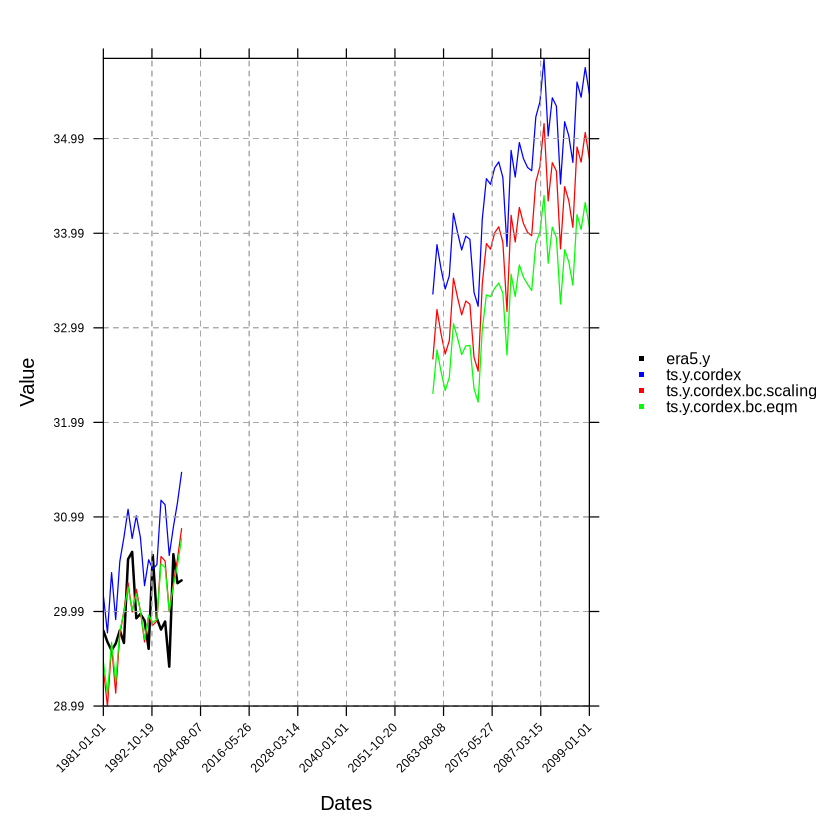

In [16]:
## aggregating to yearly time-series ##
era5.y = aggregateGrid(era5, aggr.y = list(FUN = "mean"))
cordex.hist.y = aggregateGrid(cordex.hist, aggr.y = list(FUN = "mean"))
cordex.rcp85.y = aggregateGrid(cordex.rcp85, aggr.y = list(FUN = "mean"))
cordex.hist.bc.scaling.y = aggregateGrid(cordex.hist.bc.scaling, 
                                         aggr.y = list(FUN = "mean", na.rm = TRUE))
cordex.rcp85.bc.scaling.y = aggregateGrid(cordex.rcp85.bc.scaling, 
                                          aggr.y = list(FUN = "mean", na.rm = TRUE))
cordex.hist.bc.eqm.y = aggregateGrid(cordex.hist.bc.eqm, 
                                     aggr.y = list(FUN = "mean", na.rm = TRUE))
cordex.rcp85.bc.eqm.y = aggregateGrid(cordex.rcp85.bc.eqm, 
                                      aggr.y = list(FUN = "mean", na.rm = TRUE))

## creating continuous time series ##
ts.y.cordex = bindGrid(cordex.hist.y, cordex.rcp85.y, dimension = "time")
ts.y.cordex.bc.scaling = bindGrid(cordex.hist.bc.scaling.y, cordex.rcp85.bc.scaling.y, dimension = "time")
ts.y.cordex.bc.eqm = bindGrid(cordex.hist.bc.eqm.y, cordex.rcp85.bc.eqm.y, dimension = "time")

## plotting ##
temporalPlot(era5.y, ts.y.cordex, ts.y.cordex.bc.scaling, ts.y.cordex.bc.eqm,
             cols = c("black", "blue", "red", "green"),
             lwd = c(2, 1, 1, 1))

## 9. Local Climate Projections: Karachi Airport

While spatial maps provide a broad overview of the projected climate changes, many climate services and impact studies require information at specific locations. In this section, the analysis focuses on Karachi Airport, extracting the grid cell closest to its geographical coordinates from both the observational dataset and the climate model simulations.

### 9.1. Time series
Now, daily maximum temperature series are retrieved for the historical and future simulations, together with their bias-adjusted counterparts obtained using the Scaling and Empirical Quantile Mapping (EQM) methods at the Karachi Airport. The historical and future periods are then concatenated to produce continuous time series spanning both the reference and projection periods.

Finally, the observed ERA5 record and the three model simulations (raw, Scaling-adjusted and EQM-adjusted) are displayed together. This comparison provides a clear illustration of how the different bias correction methods may modify the simulated temperatures during the historical period and how these corrections propagate into the future projections. Examining the complete daily time series also helps identify differences in variability, seasonality and long-term warming that may not be readily apparent from climatological averages alone.

pad applied on the interval: day

pad applied on the interval: day

pad applied on the interval: day

pad applied on the interval: day



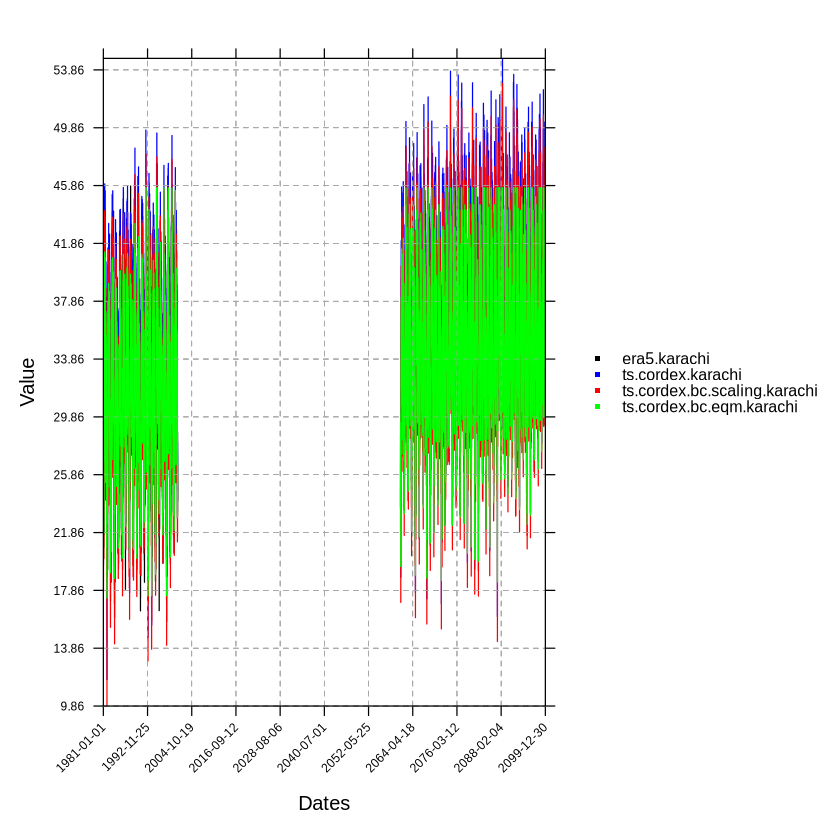

In [17]:
## projections in Karachi (airport) ##
lon.karachi = 67.133 
lat.karachi = 24.9

## daily data ##
era5.karachi = subsetGrid(era5, lonLim = lon.karachi, latLim = lat.karachi)
cordex.hist.karachi = subsetGrid(cordex.hist, lonLim = lon.karachi, latLim = lat.karachi)
cordex.hist.bc.scaling.karachi = subsetGrid(cordex.hist.bc.scaling, lonLim = lon.karachi, latLim = lat.karachi)
cordex.hist.bc.eqm.karachi = subsetGrid(cordex.hist.bc.eqm, lonLim = lon.karachi, latLim = lat.karachi)
cordex.rcp85.karachi = subsetGrid(cordex.rcp85, lonLim = lon.karachi, latLim = lat.karachi)
cordex.rcp85.bc.scaling.karachi = subsetGrid(cordex.rcp85.bc.scaling, lonLim = lon.karachi, latLim = lat.karachi)
cordex.rcp85.bc.eqm.karachi = subsetGrid(cordex.rcp85.bc.eqm, lonLim = lon.karachi, latLim = lat.karachi)

## continuous time series ##
ts.cordex.karachi = bindGrid(cordex.hist.karachi, cordex.rcp85.karachi, dimension = "time")
ts.cordex.bc.scaling.karachi = bindGrid(cordex.hist.bc.scaling.karachi, cordex.rcp85.bc.scaling.karachi, dimension = "time")
ts.cordex.bc.eqm.karachi = bindGrid(cordex.hist.bc.eqm.karachi, cordex.rcp85.bc.eqm.karachi, dimension = "time")

## plotting ##
temporalPlot(era5.karachi, 
             ts.cordex.karachi, 
             ts.cordex.bc.scaling.karachi, 
             ts.cordex.bc.eqm.karachi,
             cols = c("black", "blue", "red", "green"))

To better highlight the long-term climate signal, the analysis is repeated using yearly-aggregated data.

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year



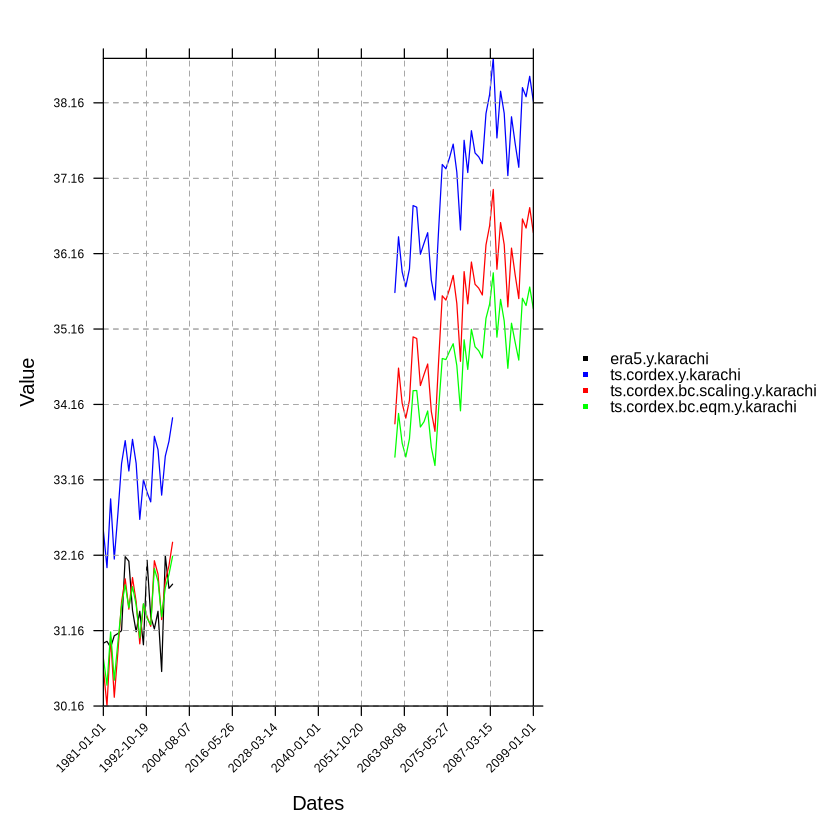

In [18]:
## yearly data ##
era5.y.karachi = subsetGrid(era5.y, lonLim = lon.karachi, latLim = lat.karachi)
cordex.hist.y.karachi = subsetGrid(cordex.hist.y, lonLim = lon.karachi, latLim = lat.karachi)
cordex.hist.bc.scaling.y.karachi = subsetGrid(cordex.hist.bc.scaling.y, lonLim = lon.karachi, latLim = lat.karachi)
cordex.hist.bc.eqm.y.karachi = subsetGrid(cordex.hist.bc.eqm.y, lonLim = lon.karachi, latLim = lat.karachi)
cordex.rcp85.y.karachi = subsetGrid(cordex.rcp85.y, lonLim = lon.karachi, latLim = lat.karachi)
cordex.rcp85.bc.scaling.y.karachi = subsetGrid(cordex.rcp85.bc.scaling.y, lonLim = lon.karachi, latLim = lat.karachi)
cordex.rcp85.bc.eqm.y.karachi = subsetGrid(cordex.rcp85.bc.eqm.y, lonLim = lon.karachi, latLim = lat.karachi)

## continuous time series ##
ts.cordex.y.karachi = bindGrid(cordex.hist.y.karachi, cordex.rcp85.y.karachi, dimension = "time")
ts.cordex.bc.scaling.y.karachi = bindGrid(cordex.hist.bc.scaling.y.karachi, cordex.rcp85.bc.scaling.y.karachi, dimension = "time")
ts.cordex.bc.eqm.y.karachi = bindGrid(cordex.hist.bc.eqm.y.karachi, cordex.rcp85.bc.eqm.y.karachi, dimension = "time")

## plotting ##
temporalPlot(era5.y.karachi, 
             ts.cordex.y.karachi, 
             ts.cordex.bc.scaling.y.karachi, 
             ts.cordex.bc.eqm.y.karachi,
             cols = c("black", "blue", "red", "green"))

### 9.2.  Probability Density Functions (PDFs)

In the previous analysis, we have focused on the temporal evolution of maximum temperature at Karachi Airport. Now, we adopt a different perspective by comparing the probability density functions (PDFs) of daily maximum temperature for the historical reference period and the future climate projections at this particular station. 

Density estimates are computed for four datasets: the ERA5 observations, the bias-adjusted historical simulation, and the bias-adjusted projections for the mid-century (2061-2080) and late-century (2081-2099) periods. For brevity, this is only done for the EQM method.

Plotting these distributions together provides a concise summary of how the statistical characteristics of daily maximum temperature are expected to evolve under climate change.

Unlike time series, which describe the temporal evolution of individual values, probability density functions (PDFs) characterise the overall distribution. Therefore, they allow for identifying changes not only in the average climate, but also in the frequency of extremely hot conditions. This representation is particularly useful for assessing whether climate change mainly shifts the distribution towards warmer conditions or also modifies its shape and variability.

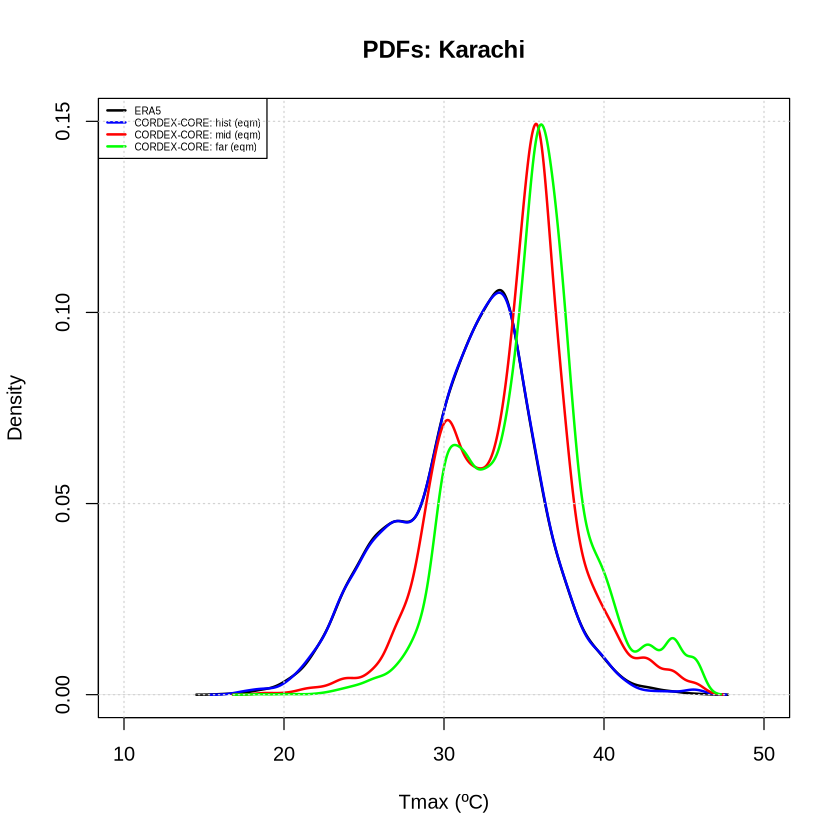

In [19]:
## PDFs in Karachi (airport) ##
pdf.era5.karachi = density(era5.karachi$Data, na.rm = TRUE)
pdf.cordex.hist.bc.eqm.karachi <- density(cordex.hist.bc.eqm.karachi$Data, na.rm = TRUE)
pdf.cordex.rcp85.bc.eqm.mid.karachi <- density(subsetGrid(cordex.rcp85.bc.eqm.karachi, years = 2061:2080)$Data, na.rm = TRUE)
pdf.cordex.rcp85.bc.eqm.far.karachi <- density(subsetGrid(cordex.rcp85.bc.eqm.karachi, years = 2081:2099)$Data, na.rm = TRUE)

## plotting ##
plot(pdf.era5.karachi, col = "black", lwd = 2,
     main = "PDFs: Karachi",
     xlab = "Tmax (ºC)", ylab = "Density",
     xlim = c(10, 50), ylim = c(0, 0.15))
lines(pdf.cordex.hist.bc.eqm.karachi, col = "blue", lwd = 2)
lines(pdf.cordex.rcp85.bc.eqm.mid.karachi, col = "red", lwd = 2)
lines(pdf.cordex.rcp85.bc.eqm.far.karachi, col = "green", lwd = 2)
legend("topleft",
       legend = c("ERA5", "CORDEX-CORE: hist (eqm)", "CORDEX-CORE: mid (eqm)", "CORDEX-CORE: far (eqm)"),
       col = c("black", "blue", "red", "green"),
       lwd = 2,
       cex = 0.5)
grid()

## 10. From Climate Variables to Climate Indices: ND35

Many environmental and socio-economic impacts are driven by temperature threshold exceedances. For this reason, impact studies frequently rely on climate indices, which transform basic climate information (e.g. maximum temperature) into variables with a more direct physical interpretation (e.g. number of days above a certain threshold).

Next, we aanalyze ND35 at Karachi (airpot). This index is defined as the annual number of days with maximum temperature above 35°C. Because ND35 is based on a fixed threshold, it provides a more direct measure of heat exposure than maximum temperature itself and is therefore widely used in climate impact assessments related to human health, agriculture and livestock production. This type of index is particularly relevant in regions where high temperatures already occur frequently, since relatively small increases in temperatures may translate into much larger increases in the number of hot days.

We compute ND35 for the ERA5 observations, the raw CORDEX-CORE simulation and the two bias-adjusted simulations obtained using the Scaling and Empirical Quantile Mapping (EQM) methods. For the climate model, the historical and future periods are first combined into a continuous time series, allowing the annual evolution of ND35 to be analysed seamlessly from the reference period to the end of the twenty-first century.

The resulting time series illustrate how the frequency of very hot days evolves under climate change and how the different bias correction methods influence this evolution. 

**Note:** Remember that threshold-based indices respond non-linearly to changes in temperature. A modest increase in the mean climate may produce a much larger increase in the number of exceedances if temperatures frequently lie close to the selected threshold.

[2026-07-17 11:20:58.427408] Performing annual aggregation...

[2026-07-17 11:20:58.428891] Done.

[2026-07-17 11:20:59.482239] Performing annual aggregation...

[2026-07-17 11:20:59.484784] Done.

[2026-07-17 11:21:00.764353] Performing annual aggregation...

[2026-07-17 11:21:00.767845] Done.

[2026-07-17 11:21:02.061678] Performing annual aggregation...

[2026-07-17 11:21:02.065057] Done.

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year

pad applied on the interval: year



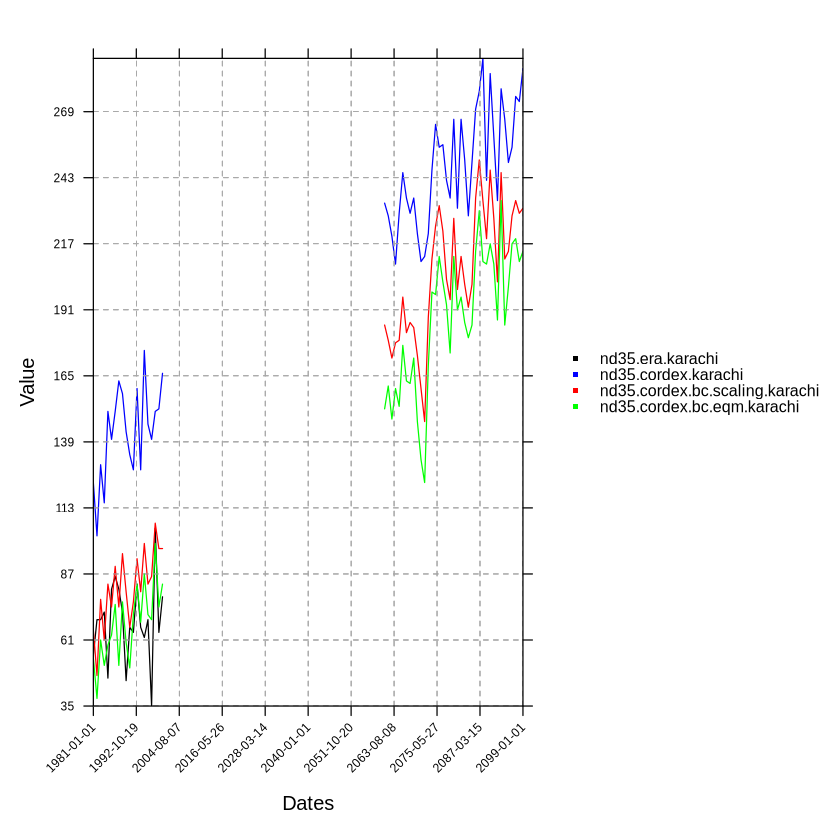

In [20]:
###############################
## ND35 at Karachi (airport) ##
###############################
nd35.era.karachi = aggregateGrid(binaryGrid(era5.karachi, condition = "GE", threshold = 35),
                                 aggr.y = list(FUN = "sum"))
nd35.cordex.karachi = aggregateGrid(binaryGrid(ts.cordex.karachi, condition = "GE", threshold = 35),
                                    aggr.y = list(FUN = "sum"))
nd35.cordex.bc.scaling.karachi = aggregateGrid(binaryGrid(ts.cordex.bc.scaling.karachi, condition = "GE", threshold = 35),
                                               aggr.y = list(FUN = "sum", na.rm = TRUE))
nd35.cordex.bc.eqm.karachi = aggregateGrid(binaryGrid(ts.cordex.bc.eqm.karachi, condition = "GE", threshold = 35),
                                           aggr.y = list(FUN = "sum", na.rm = TRUE))
## plotting ##
temporalPlot(nd35.era.karachi, nd35.cordex.karachi,
             nd35.cordex.bc.scaling.karachi, nd35.cordex.bc.eqm.karachi,
             cols = c("black", "blue", "red", "green"))

## 11. Multi-Model Climate Change Projections

So far, the analyses presented have focused on a single RCM in order to illustrate the complete bias adjustment workflow. The same methodology is now extended to multiple CORDEX-CORE simulations, allowing the consistency of the projected climate change signal to be assessed across different climate models.

For each simulation, the historical and future maximum temperature datasets are loaded and converted to degrees Celsius. The historical period (1981-2000) is then used to calibrate the Empirical Quantile Mapping (EQM) bias adjustment method, which is subsequently applied to the corresponding future projection under the RCP8.5 scenario.

Once the future simulations are bias-adjusted, the climate change signal is computed for two projection horizons: mid-century (2061-2080) and late-century (2081-2099). In both cases, the signal is expressed as the difference between the future and historical climatological maximum temperatures. Finally, the resulting delta maps are displayed for all climate models, enabling a direct comparison of the projected warming patterns and their evolution throughout the twenty-first century.

Presenting the results from several climate models provides valuable information on the robustness of the projected changes. Although individual models may differ in the magnitude of the warming, comparing their spatial patterns helps identify climate change signals that are consistently reproduced across the ensemble.

In [21]:
#########################
## more climate models ##
#########################

#model = c("HadGEM2-ES_REMO2015", "MPI-ESM-LR_REMO2015", "MPI-ESM-MR_RegCM4-7", "NorESM1-M_REMO2015","NorESM1-M_RegCM4-7")
model = c("HadGEM2-ES_REMO2015", "MPI-ESM-LR_REMO2015", "NorESM1-M_REMO2015")

## initializing output lists ##
delta.mid.bc.eqm = vector(mode = "list", length = length(model))
delta.far.bc.eqm = vector(mode = "list", length = length(model))

## looping over models ##
for (imodel in model) {
  print(sprintf("##### %s #####", imodel))
  
  ## historical ##
  cordex.hist = loadGridData(sprintf("%s/%s_historical_tmax.nc", dirdata.cordex, imodel),
                     var = "tmax", lonLim = lon, latLim = lat,
                     years = 1981:2000)
  
  ## RCP8.5 ##
  cordex.rcp85 = loadGridData(sprintf("%s/%s_rcp85_tmax.nc", dirdata.cordex, imodel),
                     var = "tmax", lonLim = lon, latLim = lat,
                     years = 2061:2099)
    
  ## converting K to degC ##
  cordex.hist = gridArithmetics(cordex.hist, 273.15, operator = "-")
  cordex.rcp85 = gridArithmetics(cordex.rcp85, 273.15, operator = "-")
  
  ##################################
  ## bias correction (eqm method) ##
  ##################################
  
  ## correcting the historical scenario (in CV mode, with 2 folds) ##
  cordex.hist.bc.eqm = biasCorrection(era5, cordex.hist, 
                                      method = "eqm", 
                                      cross.val = "kfold", folds = 2)
  cordex.hist.bc.eqm$Dates$start = as.character(cordex.hist.bc.eqm$Dates$start)  # manually fixing bug in dates after bias correction
  cordex.hist.bc.eqm$Dates$end = as.character(cordex.hist.bc.eqm$Dates$end)  # manually fixing bug in dates after bias correction

  ## correcting the RCP8.5 scenario ##
  cordex.rcp85.bc.eqm = biasCorrection(era5, cordex.hist, newdata = cordex.rcp85, 
                                       method = "eqm", 
                                       cross.val = "none")
  cordex.rcp85.bc.eqm$Dates$start = as.character(cordex.rcp85.bc.eqm$Dates$start)  # manually fixing bug in dates after bias correction
  cordex.rcp85.bc.eqm$Dates$end = as.character(cordex.rcp85.bc.eqm$Dates$end)  # manually fixing bug in dates after bias correction
  
  ## delta: cc signals ##
  delta.mid.bc.eqm[[which(model == imodel)]] = gridArithmetics(climatology(subsetGrid(cordex.rcp85.bc.eqm, years = 2061:2080)),
                                                               climatology(cordex.hist.bc.eqm), operator = "-")
  delta.far.bc.eqm[[which(model == imodel)]] = gridArithmetics(climatology(subsetGrid(cordex.rcp85.bc.eqm, years = 2081:2099)),
                                                               climatology(cordex.hist.bc.eqm), operator = "-")
}

[1] "##### HadGEM2-ES_REMO2015 #####"


[2026-07-17 11:21:02.415268] Opening dataset...

[2026-07-17 11:21:02.74573] The dataset was successfuly opened

[2026-07-17 11:21:02.751435] Defining geo-location parameters

[2026-07-17 11:21:02.785109] Defining time selection parameters

[2026-07-17 11:21:02.903243] Retrieving data subset ...

[2026-07-17 11:21:07.240729] Done

[2026-07-17 11:21:07.379758] Opening dataset...

[2026-07-17 11:21:07.662865] The dataset was successfuly opened

[2026-07-17 11:21:07.668718] Defining geo-location parameters

[2026-07-17 11:21:07.697956] Defining time selection parameters

[2026-07-17 11:21:07.849262] Retrieving data subset ...

[2026-07-17 11:21:13.314506] Done

[2026-07-17 11:21:13.465005] Trying to determine the time zone...

[2026-07-17 11:21:13.466368] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:21:13.585852] Already complete date record. Nothing was done

[2026-07-17 11:21:13.591601] Trying to determine the time zone...

[20

[1] "##### MPI-ESM-LR_REMO2015 #####"


[2026-07-17 11:21:21.409232] Opening dataset...

[2026-07-17 11:21:21.726949] The dataset was successfuly opened

[2026-07-17 11:21:21.732622] Defining geo-location parameters

[2026-07-17 11:21:21.763972] Defining time selection parameters

[2026-07-17 11:21:21.825773] Retrieving data subset ...

[2026-07-17 11:21:25.774208] Done

[2026-07-17 11:21:25.901965] Opening dataset...

[2026-07-17 11:21:26.128235] The dataset was successfuly opened

[2026-07-17 11:21:26.13413] Defining geo-location parameters

[2026-07-17 11:21:26.166286] Defining time selection parameters

[2026-07-17 11:21:26.324966] Retrieving data subset ...

[2026-07-17 11:21:31.790556] Done

[2026-07-17 11:21:32.033412] Trying to determine the time zone...

[2026-07-17 11:21:32.035756] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:21:32.11053] Already complete date record. Nothing was done

[2026-07-17 11:21:32.116099] Trying to determine the time zone...

[202

[1] "##### NorESM1-M_REMO2015 #####"


[2026-07-17 11:21:38.656056] Opening dataset...

[2026-07-17 11:21:38.961828] The dataset was successfuly opened

[2026-07-17 11:21:38.967459] Defining geo-location parameters

[2026-07-17 11:21:38.999686] Defining time selection parameters

[2026-07-17 11:21:39.060003] Retrieving data subset ...

[2026-07-17 11:21:43.032282] Done

[2026-07-17 11:21:43.162892] Opening dataset...

[2026-07-17 11:21:43.394059] The dataset was successfuly opened

[2026-07-17 11:21:43.400234] Defining geo-location parameters

[2026-07-17 11:21:43.430455] Defining time selection parameters

[2026-07-17 11:21:43.62239] Retrieving data subset ...

[2026-07-17 11:21:49.109416] Done

[2026-07-17 11:21:49.851422] Trying to determine the time zone...

[2026-07-17 11:21:49.853365] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:21:49.926895] Already complete date record. Nothing was done

[2026-07-17 11:21:49.932507] Trying to determine the time zone...

[20

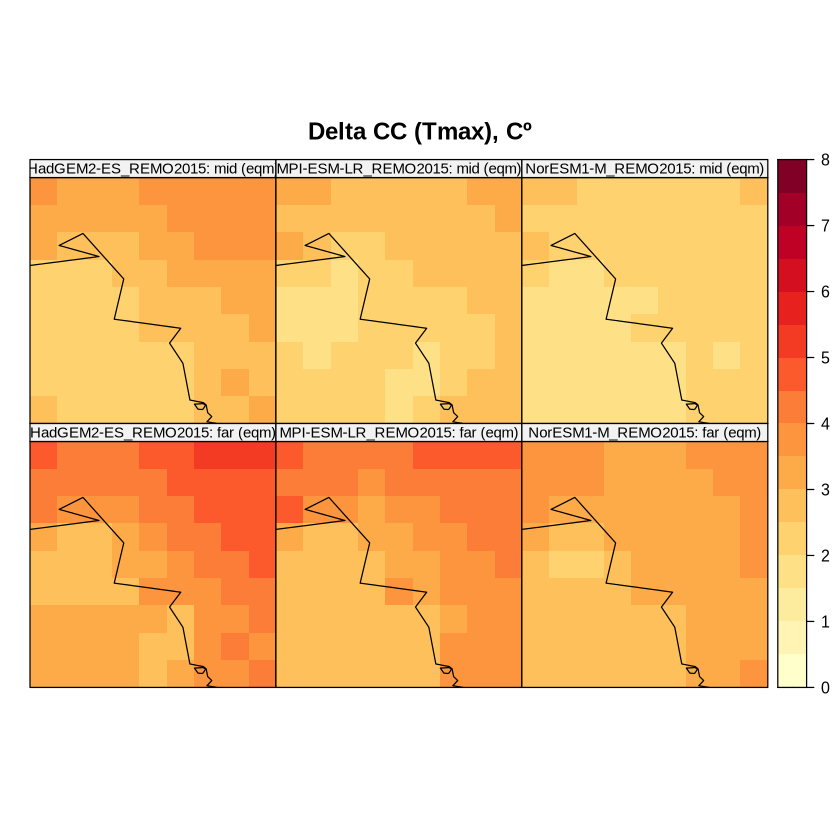

In [22]:
## plotting ##
spatialPlot(makeMultiGrid(delta.mid.bc.eqm,
                          delta.far.bc.eqm,
                          skip.temporal.check = TRUE),
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(length(model), 2),
            main = "Delta CC (Tmax), Cº",
            names.attr = c(sprintf("%s: mid (eqm)", model), 
                           sprintf("%s: far (eqm)", model)),
            par.strip.text = list(cex = 0.75),
            color.theme = "YlOrRd",
            set.min = 0, set.max = 8, at = seq(0, 8, 0.5))

Individual climate models provide plausible but uncertain representations of future climate. For this reason, climate change assessments often rely on multi-model ensembles, which combine the information from several independent simulations.

At this point, the individual climate change signals are averaged to produce the Multi-Model Ensemble Mean (MMEM). Averaging across models reduces the influence of model-specific features and highlights the climate change patterns that are consistently simulated by the ensemble.

The MMEM should not be interpreted as the "correct" projection. Rather, it represents the central tendency of the available simulations and provides a useful summary of the ensemble behaviour.

[2026-07-17 11:22:06.256194] - Computing climatology...

[2026-07-17 11:22:06.257834] - Done.

[2026-07-17 11:22:06.261517] - Computing climatology...

[2026-07-17 11:22:06.262797] - Done.



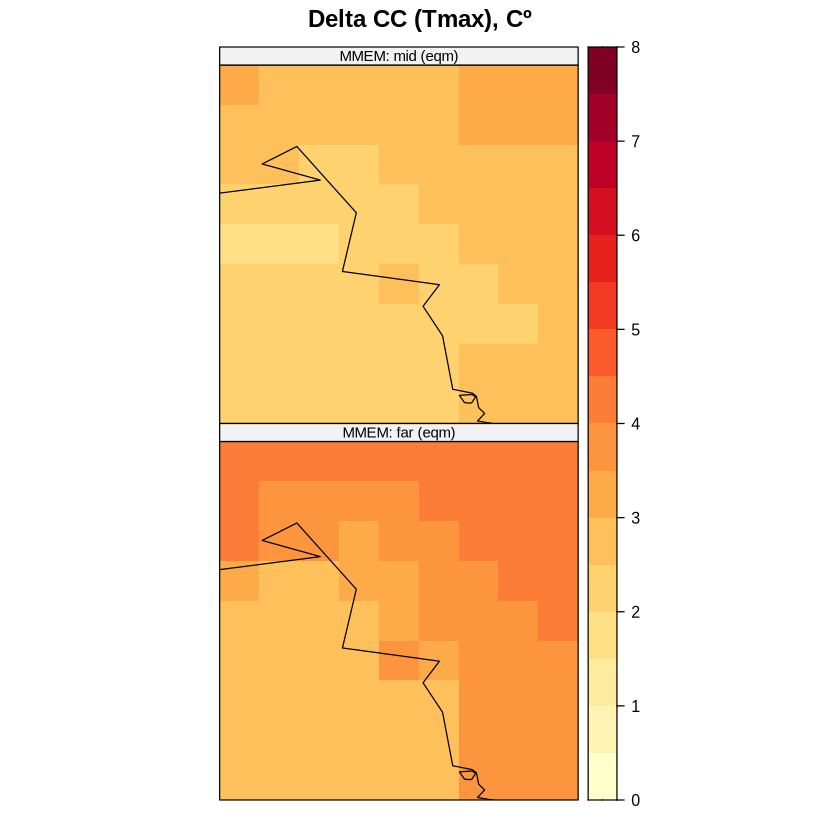

In [23]:
## MMEM ##
spatialPlot(makeMultiGrid(climatology(bindGrid(delta.mid.bc.eqm, dimension = "time")),
                          climatology(bindGrid(delta.far.bc.eqm, dimension = "time")),
                          skip.temporal.check = TRUE),
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(1, 2),
            main = "Delta CC (Tmax), Cº",
            names.attr = c("MMEM: mid (eqm)", "MMEM: far (eqm)"),
            par.strip.text = list(cex = 0.75),
            color.theme = "YlOrRd",
            set.min = 0, set.max = 8, at = seq(0, 8, 0.5))

Finally, the computed climate change signals are added to the observed historical climatology (ERA5) to generate bias-adjusted climate projections.

This approach combines two complementary sources of information:

* the observed historical climate, represented by ERA5;
* the projected climate change signal, provided by the bias-adjusted RCM simulations.

The resulting maps represent projected maximum temperatures for the mid-century (2061-2080) and late-century (2081-2099) periods. Presenting absolute projections rather than delta changes facilitates the interpretation of future climate conditions and provides a more intuitive basis for climate impact studies.

[2026-07-17 11:22:09.492497] - Computing climatology...

[2026-07-17 11:22:09.509675] - Done.

[2026-07-17 11:22:09.518184] - Computing climatology...

[2026-07-17 11:22:09.528223] - Done.

[2026-07-17 11:22:09.537522] - Computing climatology...

[2026-07-17 11:22:09.552118] - Done.

[2026-07-17 11:22:09.559751] - Computing climatology...

[2026-07-17 11:22:09.572263] - Done.

[2026-07-17 11:22:09.578678] - Computing climatology...

[2026-07-17 11:22:09.591059] - Done.

[2026-07-17 11:22:09.609293] - Computing climatology...

[2026-07-17 11:22:09.62119] - Done.



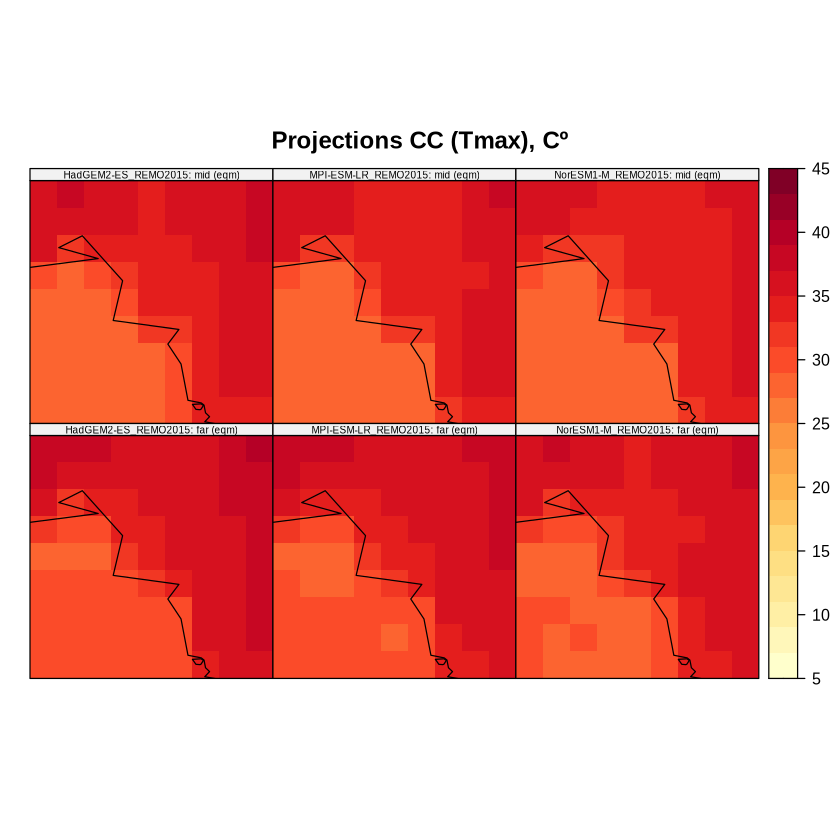

In [24]:
###############################
## future projections (maps) ##
###############################

## initializing output lists ##
proj.mid = vector(mode = "list", length = length(model))
proj.far = vector(mode = "list", length = length(model))

## looping over models ##
for (imodel in 1:length(model)) {
  proj.mid[[imodel]] = gridArithmetics(climatology(era5), delta.mid.bc.eqm[[imodel]], operator = "+")
  proj.far[[imodel]] = gridArithmetics(climatology(era5), delta.far.bc.eqm[[imodel]], operator = "+")
}

## plotting ##
spatialPlot(makeMultiGrid(proj.mid,
                          proj.far,
                          skip.temporal.check = TRUE),
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(length(model), 2),
            main = "Projections CC (Tmax), Cº",
            names.attr = c(sprintf("%s: mid (eqm)", model), 
                           sprintf("%s: far (eqm)", model)),
            par.strip.text = list(cex = 0.5),
            color.theme = "YlOrRd",
            set.min = 5, set.max = 45, at = seq(5, 45, 2))

## 12. Extending the Workflow to the Multi-Model Analysis of Future Precipitation

The analysis performed previously for maximum temperature is now extended to precipitation, following the same general workflow. ERA5 is used as the observational reference over the historical period (1981-2000), while CORDEX-CORE simulations driven by three different GCMs represent both historical and future climate conditions under the RCP8.5 scenario. Before the analysis begins, all datasets are converted to common physical units.

For each CORDEX-CORE simulation, precipitation is bias-adjusted using the Empirical Quantile Mapping (EQM) method. Since precipitation exhibits statistical characteristics that differ markedly from those of temperature (including a large number of dry days and a highly skewed distribution) the correction is performed using the precipitation-specific implementation of the EQM algorithm available in `downscaleR`. The correction is calibrated over the historical period and subsequently applied to the future projection, following the standard bias adjustment workflow introduced earlier in the notebook.

Once the bias-adjusted simulations have been obtained, climate change signals are computed for two future periods, 2061-2080 (mid-century) and 2081-2099 (late-century). In addition to changes in mean precipitation, the analysis also investigates two precipitation indices that are widely used in climate impact studies. The first is the Number of Rainy Days (NRD), defined as the annual number of days with at least 1 mm of precipitation, which provides information on changes in the frequency of wet days. The second is R50, representing the annual number of days with precipitation exceeding 50 mm, an indicator of heavy rainfall events and potential flood risk. For each variable and index, the climate change signal is calculated as the difference between the future and historical climatological conditions, providing a consistent framework for comparing projected changes across the different climate models and time horizons.

In [25]:
## loading pr from ERA5 ##
era5 = loadGridData(sprintf("%s/pr.nc", dirdata.era5),
                     var = "pr", 
                     lonLim = lon, latLim = lat,
                     years = 1981:2000)
era5 = gridArithmetics(era5, 1000, operator = "*")  # converting m/day to mm/day

## loading pr from CORDEX-CORE models ##
#model = c("HadGEM2-ES_REMO2015", "MPI-ESM-LR_REMO2015", "MPI-ESM-MR_RegCM4-7", "NorESM1-M_REMO2015","NorESM1-M_RegCM4-7")
model = c("HadGEM2-ES_REMO2015", "MPI-ESM-LR_REMO2015", "NorESM1-M_REMO2015")

## initializing output lists ##
delta.pr.mid.bc.eqm = vector(mode = "list", length = length(model))
delta.pr.far.bc.eqm = vector(mode = "list", length = length(model))

delta.nrd.mid.bc.eqm = vector(mode = "list", length = length(model))
delta.nrd.far.bc.eqm = vector(mode = "list", length = length(model))

delta.r50.mid.bc.eqm = vector(mode = "list", length = length(model))
delta.r50.far.bc.eqm = vector(mode = "list", length = length(model))

## looping over models ##
for (imodel in model) {
  print(sprintf("##### %s #####", imodel))

  ########################################  
  ## loading pr from CORDEX-CORE models ## 
  ########################################
    
  ## historical ##
  cordex.hist = loadGridData(sprintf("%s/%s_historical_pr.nc", dirdata.cordex, imodel),
                     var = "pr", lonLim = lon, latLim = lat,
                     years = 1981:2000)
  
  ## RCP8.5 ##
  cordex.rcp85 = loadGridData(sprintf("%s/%s_rcp85_pr.nc", dirdata.cordex, imodel),
                     var = "pr", lonLim = lon, latLim = lat,
                     years = 2061:2099)
    
  ## converting kg/m^2*s to mm/day ##
  cordex.hist = gridArithmetics(cordex.hist, 86400, operator = "*")
  cordex.rcp85 = gridArithmetics(cordex.rcp85, 86400, operator = "*")
    
  ##################################
  ## bias correction (eqm method) ##
  ##################################
  
  ## correcting the historical scenario (in CV mode, with 2 folds) ##
  cordex.hist.bc.eqm = biasCorrection(era5, cordex.hist, method = "eqm", 
                                      precipitation = TRUE,
                                      cross.val = "kfold", folds = 2)
  cordex.hist.bc.eqm$Dates$start = as.character(cordex.hist.bc.eqm$Dates$start)  # manually fixing bug in dates after bias correction
  cordex.hist.bc.eqm$Dates$end = as.character(cordex.hist.bc.eqm$Dates$end)  # manually fixing bug in dates after bias correction

  ## correcting the RCP8.5 scenario ##
  cordex.rcp85.bc.eqm = biasCorrection(era5, cordex.hist, newdata = cordex.rcp85, 
                                       method = "eqm", 
                                       precipitation = TRUE,
                                       cross.val = "none")
  cordex.rcp85.bc.eqm$Dates$start = as.character(cordex.rcp85.bc.eqm$Dates$start)  # manually fixing bug in dates after bias correction
  cordex.rcp85.bc.eqm$Dates$end = as.character(cordex.rcp85.bc.eqm$Dates$end)  # manually fixing bug in dates after bias correction
  
  #############################
  ## computing deltas for pr ##
  #############################
  delta.pr.mid.bc.eqm[[which(model == imodel)]] = gridArithmetics(climatology(subsetGrid(cordex.rcp85.bc.eqm, years = 2061:2080)),
                                                               climatology(cordex.hist.bc.eqm), operator = "-")
  delta.pr.far.bc.eqm[[which(model == imodel)]] = gridArithmetics(climatology(subsetGrid(cordex.rcp85.bc.eqm, years = 2081:2099)),
                                                               climatology(cordex.hist.bc.eqm), operator = "-")
  ##############################
  ## computing deltas for NRD ##
  ##############################
  nrd.cordex.hist.bc.eqm = aggregateGrid(binaryGrid(cordex.hist.bc.eqm, condition = "GE", threshold = 1),
                                       aggr.y = list(FUN = "sum", na.rm = TRUE))
  nrd.cordex.rcp85.bc.eqm = aggregateGrid(binaryGrid(cordex.rcp85.bc.eqm, condition = "GE", threshold = 1),
                                                     aggr.y = list(FUN = "sum", na.rm = TRUE))

  delta.nrd.mid.bc.eqm[[which(model == imodel)]] = gridArithmetics(climatology(subsetGrid(nrd.cordex.rcp85.bc.eqm, years = 2061:2080)),
                                                               climatology(nrd.cordex.hist.bc.eqm), operator = "-")
  delta.nrd.far.bc.eqm[[which(model == imodel)]] = gridArithmetics(climatology(subsetGrid(nrd.cordex.rcp85.bc.eqm, years = 2081:2099)),
                                                                   climatology(nrd.cordex.hist.bc.eqm), operator = "-")
  ##############################
  ## computing deltas for R50 ##
  ##############################
  r50.cordex.hist.bc.eqm = aggregateGrid(binaryGrid(cordex.hist.bc.eqm, condition = "GE", threshold = 50),
                                         aggr.y = list(FUN = "sum", na.rm = TRUE))
  r50.cordex.rcp85.bc.eqm = aggregateGrid(binaryGrid(cordex.rcp85.bc.eqm, condition = "GE", threshold = 50),
                                          aggr.y = list(FUN = "sum", na.rm = TRUE))
  
  delta.r50.mid.bc.eqm[[which(model == imodel)]] = gridArithmetics(climatology(subsetGrid(r50.cordex.rcp85.bc.eqm, years = 2061:2080)),
                                                                   climatology(r50.cordex.hist.bc.eqm), operator = "-")
  delta.r50.far.bc.eqm[[which(model == imodel)]] = gridArithmetics(climatology(subsetGrid(r50.cordex.rcp85.bc.eqm, years = 2081:2099)),
                                                                   climatology(r50.cordex.hist.bc.eqm), operator = "-")
}

[2026-07-17 11:22:20.019709] Opening dataset...

[2026-07-17 11:22:20.33999] The dataset was successfuly opened

[2026-07-17 11:22:20.345321] Defining geo-location parameters

[2026-07-17 11:22:20.376957] Defining time selection parameters

[2026-07-17 11:22:20.456156] Retrieving data subset ...

[2026-07-17 11:22:23.780543] Done



[1] "##### HadGEM2-ES_REMO2015 #####"


[2026-07-17 11:22:24.034559] Opening dataset...

[2026-07-17 11:22:24.24301] The dataset was successfuly opened

[2026-07-17 11:22:24.248972] Defining geo-location parameters

[2026-07-17 11:22:24.27777] Defining time selection parameters

[2026-07-17 11:22:24.338101] Retrieving data subset ...

[2026-07-17 11:22:27.943262] Done

[2026-07-17 11:22:28.070922] Opening dataset...

[2026-07-17 11:22:28.296289] The dataset was successfuly opened

[2026-07-17 11:22:28.302004] Defining geo-location parameters

[2026-07-17 11:22:28.33298] Defining time selection parameters

[2026-07-17 11:22:28.482357] Retrieving data subset ...

[2026-07-17 11:22:33.602847] Done

[2026-07-17 11:22:34.566561] Trying to determine the time zone...

[2026-07-17 11:22:34.568209] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:22:34.986143] Already complete date record. Nothing was done

[2026-07-17 11:22:34.991682] Trying to determine the time zone...

[2026

[1] "##### MPI-ESM-LR_REMO2015 #####"


[2026-07-17 11:22:43.200348] Opening dataset...

[2026-07-17 11:22:43.509773] The dataset was successfuly opened

[2026-07-17 11:22:43.515354] Defining geo-location parameters

[2026-07-17 11:22:43.548768] Defining time selection parameters

[2026-07-17 11:22:43.637881] Retrieving data subset ...

[2026-07-17 11:22:47.34813] Done

[2026-07-17 11:22:47.487024] Opening dataset...

[2026-07-17 11:22:47.720038] The dataset was successfuly opened

[2026-07-17 11:22:47.725333] Defining geo-location parameters

[2026-07-17 11:22:47.755814] Defining time selection parameters

[2026-07-17 11:22:48.070266] Retrieving data subset ...

[2026-07-17 11:22:53.30483] Done

[2026-07-17 11:22:53.474758] Trying to determine the time zone...

[2026-07-17 11:22:53.477187] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:22:53.567572] Already complete date record. Nothing was done

[2026-07-17 11:22:53.574782] Trying to determine the time zone...

[202

[1] "##### NorESM1-M_REMO2015 #####"


[2026-07-17 11:23:02.326589] Opening dataset...

[2026-07-17 11:23:02.639639] The dataset was successfuly opened

[2026-07-17 11:23:02.645967] Defining geo-location parameters

[2026-07-17 11:23:02.677316] Defining time selection parameters

[2026-07-17 11:23:02.7393] Retrieving data subset ...

[2026-07-17 11:23:06.451672] Done

[2026-07-17 11:23:06.590928] Opening dataset...

[2026-07-17 11:23:06.816966] The dataset was successfuly opened

[2026-07-17 11:23:06.828131] Defining geo-location parameters

[2026-07-17 11:23:06.868772] Defining time selection parameters

[2026-07-17 11:23:07.025068] Retrieving data subset ...

[2026-07-17 11:23:12.408127] Done

[2026-07-17 11:23:12.543758] Trying to determine the time zone...

[2026-07-17 11:23:12.545404] Time zone identified and set to GMT
See 'setGridDates.asPOSIXlt' to change the time zone

[2026-07-17 11:23:12.628359] Already complete date record. Nothing was done

[2026-07-17 11:23:12.633637] Trying to determine the time zone...

[202

### 12.1. Comparing Climate Change Signals Across the Multi-Model Ensemble

The climate change signals computed in the previous block of code are now visualised for each of the three CORDEX-CORE simulations. Separate maps are produced for precipitation, NRD and R50, considering both the mid-century (2061-2080) and late-century (2081-2099) periods.

Displaying the projections side by side facilitates a direct comparison of the simulated changes across models and time horizons. This makes it possible to identify regions where the different simulations consistently project similar changes, as well as areas where greater disagreement exists. Such comparisons are particularly useful for assessing the robustness of projected climate changes and for identifying patterns that are common to the ensemble rather than specific to an individual model.

Note that the three variables provide complementary information about future changes in the hydrological cycle. While mean precipitation describes changes in the overall amount of rainfall, NRD reflects changes in the frequency of wet days, and R50 characterises the occurrence of heavy precipitation events. Analysing these variables together helps distinguish whether projected changes arise from more frequent rainfall, more intense rainfall, or a combination of both.

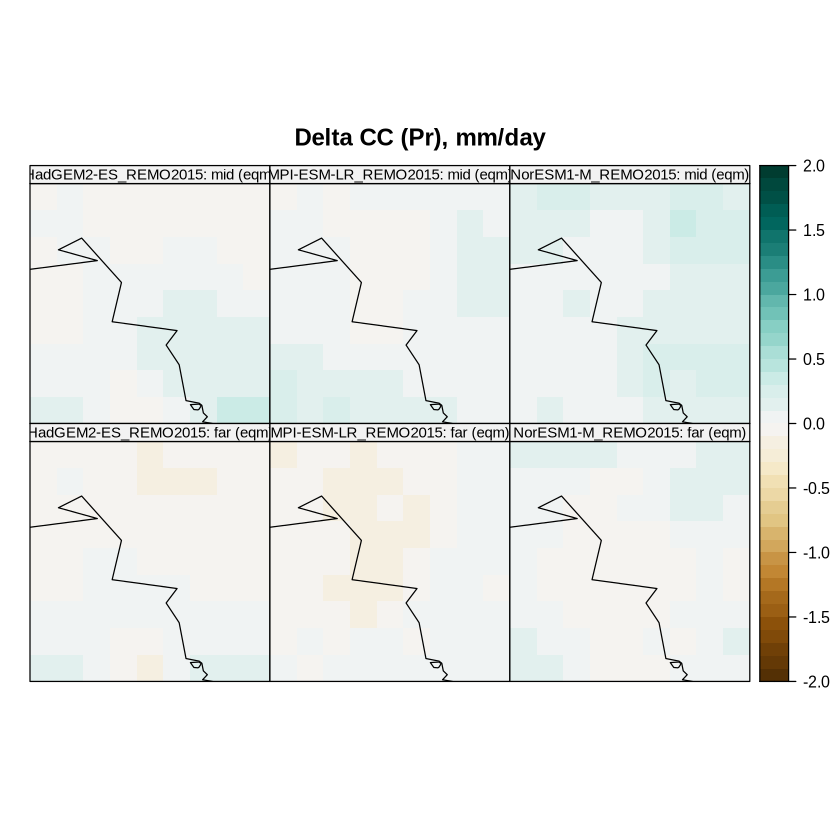

In [26]:
## plotting deltas for pr ##
spatialPlot(makeMultiGrid(delta.pr.mid.bc.eqm,
                          delta.pr.far.bc.eqm,
                          skip.temporal.check = TRUE),
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(length(model), 2),
            main = "Delta CC (Pr), mm/day",
            names.attr = c(sprintf("%s: mid (eqm)", model), 
                           sprintf("%s: far (eqm)", model)),
            par.strip.text = list(cex = 0.75),
            color.theme = "BrBG",
            set.min = -2, set.max = 2, at = seq(-2, 2, 0.1))

[2026-07-17 11:23:32.50385] Performing annual aggregation...

[2026-07-17 11:23:32.516662] Done.



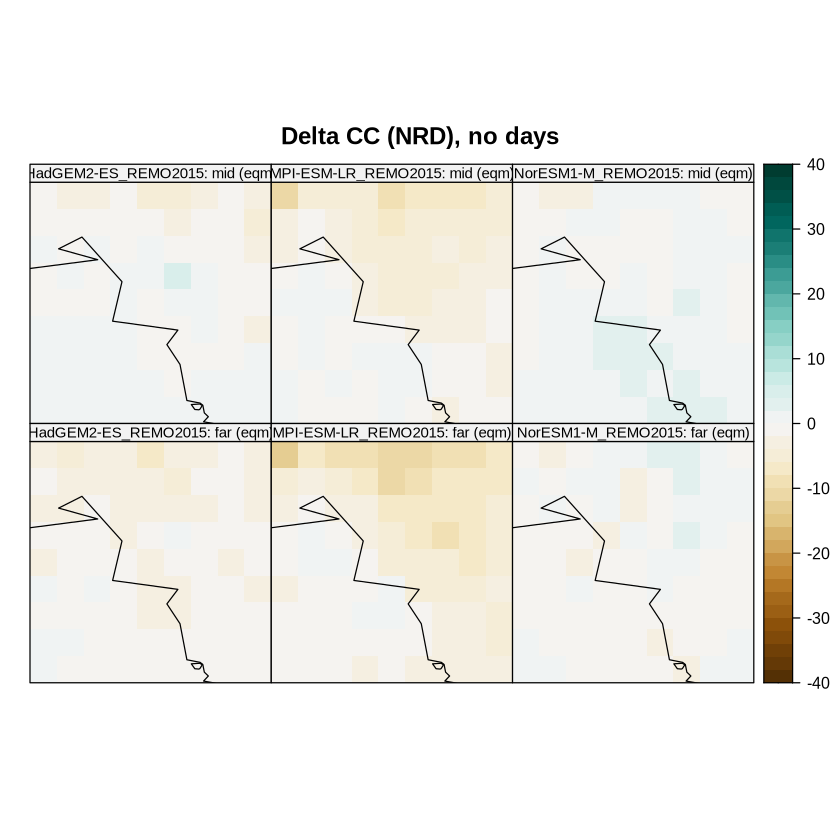

In [27]:
## plotting deltas for NRD ##
nrd.era5 = aggregateGrid(binaryGrid(era5, condition = "GE", threshold = 1),
                         aggr.y = list(FUN = "sum"))
spatialPlot(makeMultiGrid(delta.nrd.mid.bc.eqm,
                          delta.nrd.far.bc.eqm,
                          skip.temporal.check = TRUE),
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(length(model), 2),
            main = "Delta CC (NRD), no days",
            names.attr = c(sprintf("%s: mid (eqm)", model), 
                           sprintf("%s: far (eqm)", model)),
            par.strip.text = list(cex = 0.75),
            color.theme = "BrBG",
            set.min = -40, set.max = 40, at = seq(-40, 40, 2))

[2026-07-17 11:23:45.590264] Performing annual aggregation...

[2026-07-17 11:23:45.603081] Done.



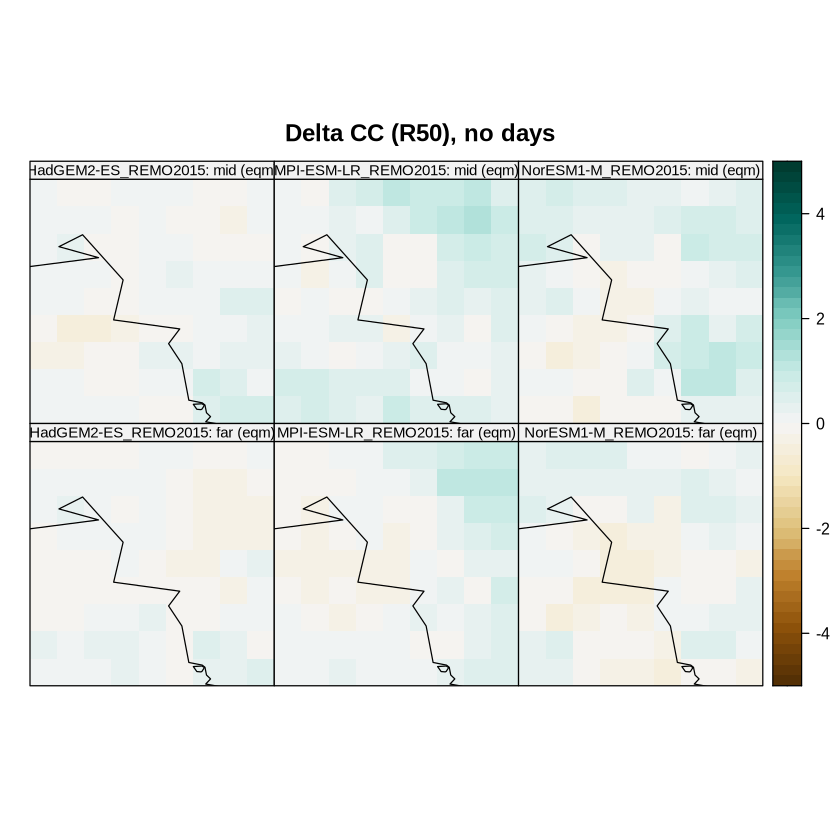

In [28]:
## plotting deltas for R50 ##
r50.era5 = aggregateGrid(binaryGrid(era5, condition = "GE", threshold = 50),
                         aggr.y = list(FUN = "sum"))
spatialPlot(makeMultiGrid(delta.r50.mid.bc.eqm,
                          delta.r50.far.bc.eqm,
                          skip.temporal.check = TRUE),
            backdrop.theme = "countries",
            as.table = TRUE,
            layout = c(length(model), 2),
            main = "Delta CC (R50), no days",
            names.attr = c(sprintf("%s: mid (eqm)", model), 
                           sprintf("%s: far (eqm)", model)),
            par.strip.text = list(cex = 0.75),
            color.theme = "BrBG",
            set.min = -5, set.max = 5, at = seq(-5, 5, 0.2))

## 13. Further Exercises

This notebook has introduced the complete workflow for bias correction of regional climate models. The analyses presented could be easily extended to:

* Compare the projected climate change signals provided by REMO2015 and RegCM4. Assess the uncertainty associated with the choice of RCM.
* Analyse how the projected climate change signals differ for different emission scenarios (i.e. RCP4.5 vs. RCP8.5). 
* Extend the station-based analysis beyond Karachi by selecting stations located in different climatic regions of Pakistan. Compare how projected warming and precipitation changes vary between coastal, mountainous and arid environments.
* Compare the future projections obtained with other bias correction methods beyond Scaling and EQM. Identify regions where the uncertainty associated to the choice of bias correction method is larger.

Exploring these extensions will provide a deeper understanding of both the capabilities and the limitations of bias correction for climate change applications.